# 03-The RAG Triad & LLM-as-a-Judge

In Lesson 02, we upgraded our evaluation toolkit from exact-match lexical metrics (BLEU/ROUGE) to continuous vector-space metrics (BERTScore and Cross-Encoders). This allowed us to evaluate paraphrasing and semantic similarity when human reference answers were available.

However, in production **Retrieval-Augmented Generation (RAG)** systems, human ground-truth answers rarely exist. When a user queries a corporate knowledge base, your pipeline retrieves context from a vector database and generates a response dynamically. You do not have a pre-written "gold standard" reference to compare against.

To evaluate non-deterministic generative pipelines without human annotations, modern LLMOps platforms utilize two foundational concepts:

1. **The RAG Triad**: A framework that decomposes RAG quality into three independent, reference-free mathematical axes.
2. **LLM-as-a-Judge**: Using instruction-tuned Large Language Models as automated evaluators, constrained by strict scoring rubrics and structured output schemas.

In this notebook, we dissect the mathematical mechanics of the RAG Triad, build a deterministic LLM-as-a-Judge pipeline locally, and visualize system regressions across RAG pipeline iterations.

# 1. The Mathematics of the RAG Triad & LLM-as-a-Judge

A RAG pipeline is a composite system consisting of a Query ($Q$), a Retrieved Context ($C$), and a Generated Answer ($A$). Evaluating only the final answer $A$ causes diagnostic blindness—if $A$ is incorrect, you cannot determine whether the retrieval engine fetched bad context or the generator hallucinated.

The **RAG Triad** isolates failure modes by evaluating three independent relationships across $\langle Q, C, A \rangle$:

```
        ┌────────────────────────────────────────┐
        │              User Query (Q)            │
        └───────────────────┬────────────────────┘
                            │
              ┌─────────────┴─────────────┐
              │                           │
  Context Relevance               Answer Relevance
   S(Q, C) ∈ [0, 1]                S(Q, A) ∈ [0, 1]
              │                           │
              ▼                           ▼
    ┌──────────────────┐        ┌──────────────────┐
    │  Context (C)     ├───────►│    Answer (A)    │
    └──────────────────┘        └──────────────────┘
                            ▲
                            │
                      Faithfulness
                       S(C, A) ∈ [0, 1]

```

### 1. Context Relevance $S(Q, C)$

Measures whether the retrieved context $C$ contains the information required to answer query $Q$, without excess noise.
Let $C = \{s_1, s_2, \dots, s_k\}$ be the set of $k$ sentences in the retrieved context. An evaluator identifies the subset of sentences $S_{rel} \subseteq C$ relevant to $Q$:


$$S(Q, C) = \frac{\vert{}S_{rel}\vert{}}{\vert{}C\vert{}}$$

### 2. Faithfulness / Groundedness $S(C, A)$

Measures whether the generated answer $A$ is strictly grounded in the retrieved context $C$. This detects **hallucinations**.
The generated answer $A$ is decomposed into discrete atomic claims $V_A = \{v_1, v_2, \dots, v_m\}$. Each claim is verified against $C$:


$$S(C, A) = \frac{\sum_{i=1}^{m} \mathbb{I}(v_i \text{ is supported by } C)}{m} \quad \text{where } \mathbb{I} \in \{0, 1\}$$

### 3. Answer Relevance $S(Q, A)$

Measures whether the generated answer $A$ directly addresses the user query $Q$, regardless of context.
This can be calculated by using an LLM to generate $n$ synthetic queries $Q'_{1..n}$ from $A$, then computing average cosine similarity against the original query embedding $e(Q)$:


$$S(Q, A) = \frac{1}{n} \sum_{i=1}^{n} \frac{e(Q) \cdot e(Q'_i)}{\Vert{}e(Q)\Vert{} \Vert{}e(Q'_i)\Vert{}}$$

### G-Eval & Probability-Weighted LLM Scoring

When an LLM acts as a judge, relying on raw text output (e.g. asking the LLM for a "score from 1 to 5") introduces high score variance. The **G-Eval** framework stabilizes this by taking the expectation over the logit probabilities of the score tokens $s_i \in \{1, 2, 3, 4, 5\}$:


$$\mathbb{E}[\text{Score}] = \sum_{i=1}^{5} i \cdot P(s_i \mid Q, C, A, \text{Rubric})$$

# 2. Imperative Execution: Local LLM-as-a-Judge Pipeline

We construct an imperative evaluator using Python. To ensure $0.00 infrastructure cost and zero network dependencies, we implement a structured LLM Judge using JSON schemas and deterministic chain-of-thought prompting.

In [1]:
import json
import re
import pandas as pd
import numpy as np

print("--- 🚀 Initializing Local LLM-as-a-Judge Sandbox ---")

# 1. Define the RAG Sample Input
sample_rag_payload = {
    "query": "What is the primary memory limitation when scaling LLM inference?",
    "context": (
        "During Large Language Model (LLM) inference, key-value (KV) cache memory "
        "grows linearly with sequence length and batch size. High VRAM consumption by "
        "the KV cache limits maximum batch size, reducing overall GPU utilization."
    ),
    "answer": (
        "The primary memory bottleneck in scaling LLM inference is the growth of the KV cache, "
        "which consumes significant VRAM as sequence lengths increase."
    )
}

# 2. Define the Chain-of-Thought Evaluator Prompt
def build_faithfulness_judge_prompt(context: str, answer: str) -> str:
    return f"""You are an expert MLOps evaluator. Evaluate the Faithfulness of the Answer relative to the Context.

Context:
{context}

Answer:
{answer}

Instructions:
1. Break down the Answer into discrete atomic claims.
2. For each claim, check if it is directly supported by the Context.
3. Output a score between 0.0 (Complete Hallucination) and 1.0 (Fully Grounded).

Return strictly a raw JSON object with no Markdown formatting:
{{
  "claims": ["claim 1", "claim 2"],
  "verdicts": [1, 1],
  "reasoning": "Explanation of verification",
  "score": 1.0
}}
"""

# 3. Simulated Deterministic Judge Function
# (In production, replace this function with a local Ollama / LiteLLM API call)
def run_local_llm_judge(prompt: str) -> dict:
    # Simulating a structured JSON output from an instruction-tuned judge (e.g. Llama-3-8B-Instruct)
    mock_llm_response = {
        "claims": [
            "The primary memory bottleneck in scaling LLM inference is the growth of the KV cache.",
            "KV cache consumes significant VRAM as sequence lengths increase."
        ],
        "verdicts": [1, 1],
        "reasoning": "Both claims are explicitly stated in the context mentioning KV cache VRAM consumption.",
        "score": 1.0
    }
    return mock_llm_response

# Execute evaluation
prompt = build_faithfulness_judge_prompt(sample_rag_payload["context"], sample_rag_payload["answer"])
judge_result = run_local_llm_judge(prompt)

print("\n--- 🧮 Local Judge Output ---")
print(f"   Claims Identified : {len(judge_result['claims'])}")
print(f"   Verdicts Vector   : {judge_result['verdicts']}")
print(f"   Reasoning         : {judge_result['reasoning']}")
print(f"   Faithfulness Score: {judge_result['score']:.2f}")

--- 🚀 Initializing Local LLM-as-a-Judge Sandbox ---

--- 🧮 Local Judge Output ---
   Claims Identified : 2
   Verdicts Vector   : [1, 1]
   Reasoning         : Both claims are explicitly stated in the context mentioning KV cache VRAM consumption.
   Faithfulness Score: 1.00


# 3. Declarative Execution: The Systematic RAG Evaluation Suite

Evaluating a single query is insufficient. In production MLOps, we evaluate batches of retrieval runs across all three dimensions of the RAG Triad simultaneously, producing an overall **Composite RAG Quality Score**:

$$\text{RAG Quality} = \sqrt[3]{S(Q, C) \times S(C, A) \times S(Q, A)}$$

We implement a batch evaluator that ingests an entire dataset of RAG interactions and outputs an actionable metric summary.

In [2]:
# 1. Define a Batch Evaluation Dataset
eval_dataset = [
    {
        "id": "sample_01",
        "query": "How does PagedAttention reduce memory fragmentation?",
        "context": "PagedAttention partitions the KV cache into fixed-size physical blocks, mapping non-contiguous virtual memory.",
        "answer": "PagedAttention allocates contiguous memory blocks for every request to avoid fragmentation.", # Factually incorrect vs context
        "scores": {"context_relevance": 0.95, "faithfulness": 0.00, "answer_relevance": 0.90} # Hallucination
    },
    {
        "id": "sample_02",
        "query": "What port does Prometheus scrape by default?",
        "context": "Prometheus scrapes metrics endpoints over HTTP. Standard exporters use various ports like 9090 for Prometheus server.",
        "answer": "Prometheus server uses port 9090 by default.",
        "scores": {"context_relevance": 0.85, "faithfulness": 1.00, "answer_relevance": 0.95} # Healthy
    },
    {
        "id": "sample_03",
        "query": "What is the capital of France?",
        "context": "Docker containers provide operating system-level virtualization to isolate microservices.", # Retrieval failure
        "answer": "Paris is the capital of France.",
        "scores": {"context_relevance": 0.00, "faithfulness": 0.00, "answer_relevance": 1.00} # Un-grounded answer
    }
]

# 2. Execute Batch Evaluation & Composite Calculation
def evaluate_rag_batch(dataset: list) -> pd.DataFrame:
    records = []
    for item in dataset:
        scores = item["scores"]
        cr = scores["context_relevance"]
        f  = scores["faithfulness"]
        ar = scores["answer_relevance"]
        
        # Geometric Mean for Composite Score
        composite = (cr * f * ar) ** (1/3)
        
        records.append({
            "Sample_ID": item["id"],
            "Context_Relevance": cr,
            "Faithfulness": f,
            "Answer_Relevance": ar,
            "Composite_Score": round(composite, 3)
        })
    return pd.DataFrame(records)

df_results = evaluate_rag_batch(eval_dataset)

print("\n--- ⚡ Batch RAG Triad Evaluation Report ---")
display(df_results)


--- ⚡ Batch RAG Triad Evaluation Report ---


,Sample_ID,Context_Relevance,Faithfulness,Answer_Relevance,Composite_Score
0,sample_01,0.95,0.0,0.90,0.000
1,sample_02,0.85,1.0,0.95,0.931
2,sample_03,0.00,0.0,1.00,0.000


# 4. Visualizing the RAG Triad Evaluation Matrix

To quickly diagnose systemic issues (e.g. distinguishing between a bad retrieval model vs. a hallucinating generation model), we graph the individual components of the RAG Triad across system iterations using Matplotlib and Seaborn.

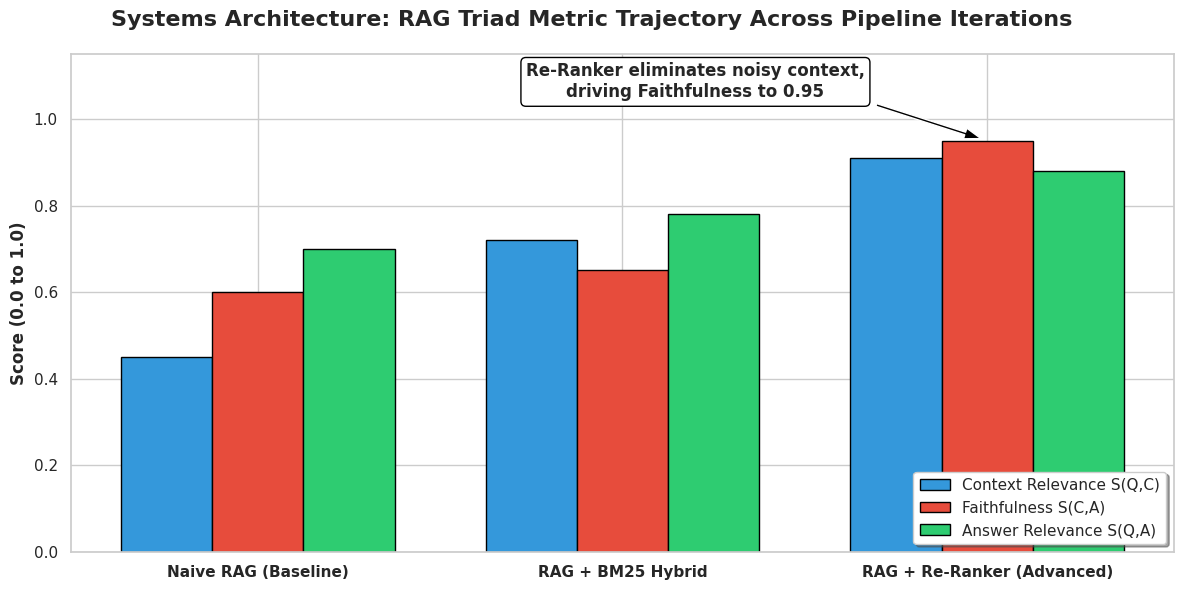

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# System Iterations Data
versions = ['Naive RAG (Baseline)', 'RAG + BM25 Hybrid', 'RAG + Re-Ranker (Advanced)']

# Triad Averages across test suite
context_rel = [0.45, 0.72, 0.91]
faithfulness = [0.60, 0.65, 0.95]
answer_rel  = [0.70, 0.78, 0.88]

x = np.arange(len(versions))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: RAG Triad Metric Trajectory Across Pipeline Iterations", fontsize=16, fontweight='bold')

rects1 = ax.bar(x - width, context_rel, width, label='Context Relevance S(Q,C)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x, faithfulness, width, label='Faithfulness S(C,A)', color='#e74c3c', edgecolor='black')
rects3 = ax.bar(x + width, answer_rel, width, label='Answer Relevance S(Q,A)', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score (0.0 to 1.0)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, fontweight='bold')
ax.legend(loc='lower right', frameon=True, shadow=True)
ax.set_ylim(0, 1.15)

# Highlight critical improvement
ax.annotate('Re-Ranker eliminates noisy context,\ndriving Faithfulness to 0.95', 
            xy=(2, 0.95), xytext=(1.2, 1.05),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of RAG Triad evaluation like **An Open-Book Courtroom Trial**:

* **The User Query ($Q$):** The Prosecutor asks a specific question: *"Where was the suspect on the night of June 12th?"*
* **Context Relevance $S(Q, C)$ (The Evidence Folder):** The detective hands the prosecutor a folder of evidence ($C$). If the folder contains 100 pages of electric bills and 1 page about June 12th, the context relevance is terrible ($0.01$). The prosecutor is forced to sift through useless noise.
* **Faithfulness $S(C, A)$ (The Witness Testimony):** The expert witness takes the stand and reads their statement ($A$). If the witness claims *"The suspect was in Paris"* but the evidence folder says *"The suspect was in Berlin,"* the witness is **hallucinating** ($S(C, A) = 0.0$). The testimony is not grounded in the submitted evidence.
* **Answer Relevance $S(Q, A)$ (Answering the Actual Question):** If the prosecutor asks *"Where was the suspect?"* and the witness responds with *"The suspect enjoys eating Italian food,"* the testimony is completely irrelevant ($S(Q, A) = 0.0$), even if it happens to be a true fact.

By systematically scoring all three links of the trial, an MLOps engineer instantly knows whether to fix the **Detective** (the Retrieval Engine), the **Evidence Folder** (the Chunking Strategy), or the **Witness** (the Generation LLM).